In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

(757, 799, 3)


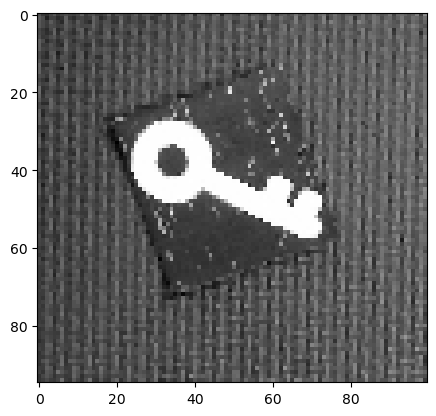

(95, 100)


In [2]:
# Leyendo los datos de la imagen
img = cv2.imread( 'Imagenes/llave1.jpg' )
print(img.shape)
escala = 1/8
img = cv2.resize( img, ( round( escala * img.shape[1] ), round( escala * img.shape[0] ) ) )
imgGray = cv2.cvtColor( img, cv2.COLOR_RGB2GRAY )

plt.imshow( imgGray, cmap='gray' )
plt.show()
print(imgGray.shape)

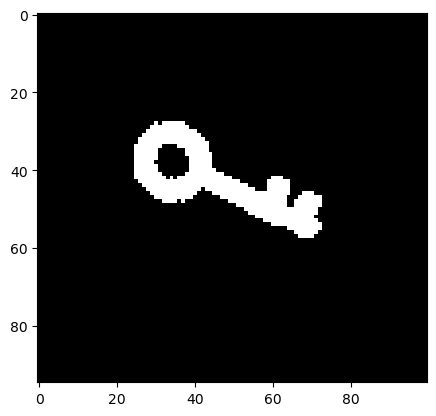

In [3]:
# Aplicando el binarizado para saber si existe un contorno

t, imgBin = cv2.threshold( imgGray, 245, 1, cv2.THRESH_BINARY )
plt.imshow( imgBin, cmap='gray' ) # No olvidar el cmap, la imagen podría salir con otra escala de colores
plt.show()

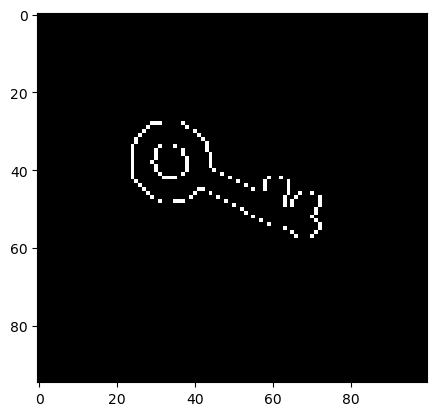

In [4]:
# Calculando el gradiente en X

kernel_x = [ -1, 1 ]
derivada_x = np.zeros( ( imgBin.shape[0], imgBin.shape[1] ) )

for i in range(imgBin.shape[0]):
    for j in range( imgBin.shape[1] ):
        conv = np.sum( kernel_x * imgBin[ i, j : j + 2] )
        derivada_x[ i, j ] = conv
derivada_x = abs(derivada_x)
plt.imshow(derivada_x, cmap='gray')
plt.show()

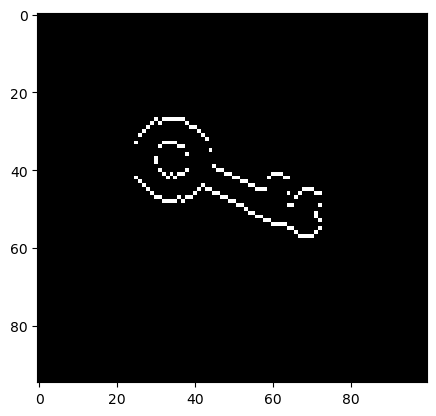

In [5]:
kernel_y = [ -1, 1 ]
derivada_y = np.zeros( ( imgBin.shape[0], imgBin.shape[1] ) )

for j in range(imgBin.shape[1]):
    for i in range( imgBin.shape[0] ):
        conv = np.sum( kernel_y * imgBin[ i : i + 2, j] )
        derivada_y[ i, j ] = conv
derivada_y = abs(derivada_y)
plt.imshow(derivada_y, cmap='gray')
plt.show()

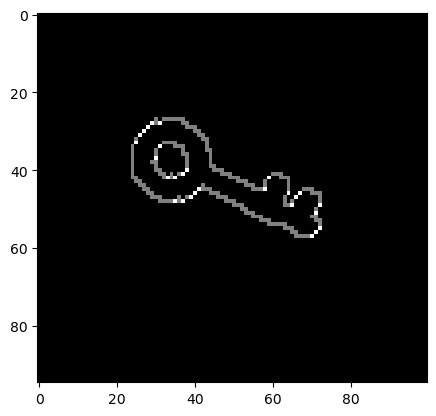

In [6]:
imgFinal = derivada_x + derivada_y
imgFinal = imgFinal
plt.imshow(imgFinal, cmap='gray')
plt.show()

## Con algoritmo SOBEL

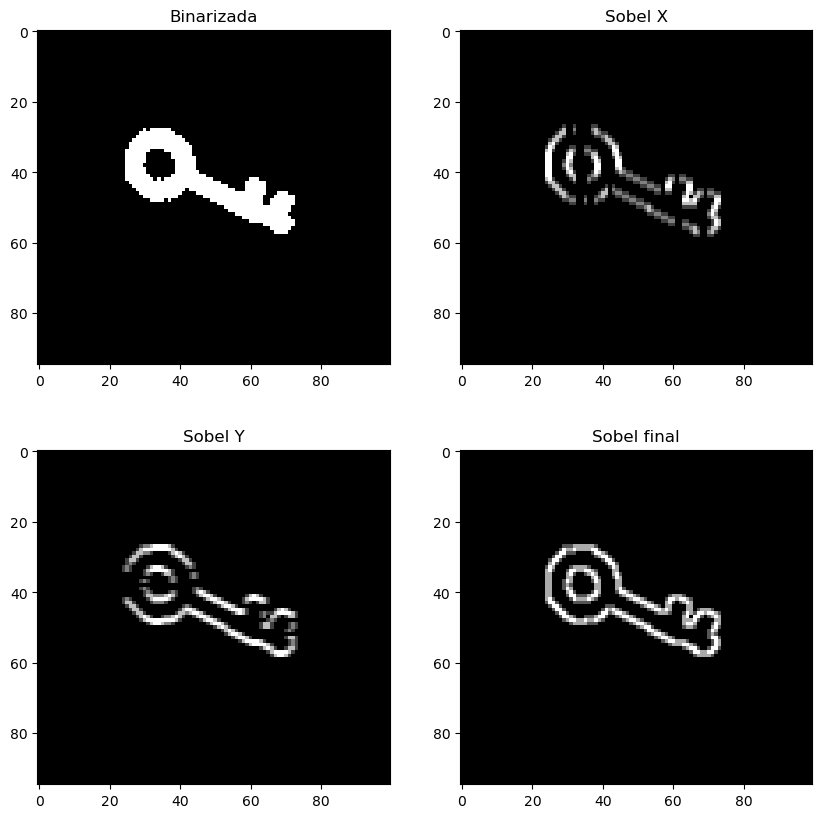

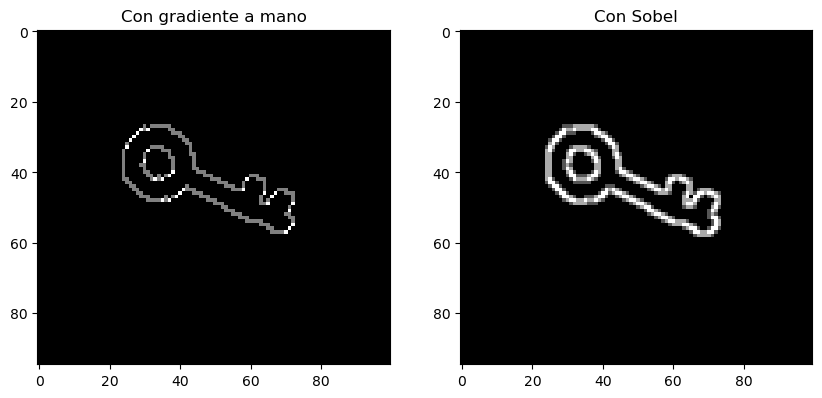

In [8]:
sobel_x = cv2.Sobel( imgBin, cv2.CV_64F, 1, 0, ksize = 3 )
sobel_y = cv2.Sobel( imgBin, cv2.CV_64F, 0, 1, ksize = 3 )

plt.figure( figsize = ( 10, 10 ) )
plt.subplot( 2, 2, 1 )
plt.imshow( imgBin, cmap='gray' )
plt.title( "Binarizada" )
plt.subplot( 2, 2, 2 )
plt.imshow( abs( sobel_x ), cmap='gray' )
plt.title( "Sobel X" )
plt.subplot( 2, 2, 3 )
plt.imshow( abs( sobel_y ), cmap='gray' )
plt.title( "Sobel Y" )
plt.subplot( 2, 2, 4 )
plt.imshow( abs( sobel_x ) + abs( sobel_y ), cmap='gray' )
plt.title( "Sobel final" )



plt.figure( figsize = ( 10, 10 ) )
plt.subplot( 1, 2, 1 )
plt.imshow( imgFinal, cmap='gray' )
plt.title( "Con gradiente a mano" )
plt.subplot( 1, 2, 2 )
plt.imshow( abs( sobel_x ) + abs( sobel_y ), cmap='gray' )
plt.title( "Con Sobel" )


plt.show()